# Analysis of Meta, CoT, and Decomposition F1 Scores

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


## Load CSV Files

In [3]:
decomposition_df = pd.read_csv('/Users/harshavardhank/Desktop/Code/UPenn/TTQA-Recasting/Benchmark/src/scripts/models/responses/New/finqa/finqa_decomposition_results.csv')
cot_df = pd.read_csv('/Users/harshavardhank/Desktop/Code/UPenn/TTQA-Recasting/Benchmark/src/scripts/models/responses/New/finqa/finqa_cot_results.csv')
meta_df = pd.read_csv('/Users/harshavardhank/Desktop/Code/UPenn/TTQA-Recasting/Benchmark/src/scripts/models/responses/New/finqa/finqa_meta_results.csv')

## Extract Relevant Columns and Merge DataFrames

In [4]:
#Extract relevant columns for comparison
decomposition_df_relevant = decomposition_df[['question', 'response', 'f1_score']]
cot_df_relevant = cot_df[['question', 'response', 'f1_score']]
meta_df_relevant = meta_df[['question', 'response', 'f1_score']]

#Merge the dataframes on the 'question' column to align responses and F1 scores
merged_df = meta_df_relevant.merge(decomposition_df_relevant, on='question', suffixes=('_meta', '_decomposition'))
merged_df = merged_df.merge(cot_df_relevant, on='question', suffixes=('', '_cot'))

merged_df.rename(columns={'response': 'response_cot', 'f1_score': 'f1_score_cot'}, inplace=True)

## Filter and Highlight Approaches

In [5]:
# Filter rows where Meta F1 score is less than either Decomposition or CoT F1 scores
filtered_df = merged_df[(merged_df['f1_score_meta'] < merged_df['f1_score_decomposition']) | (merged_df['f1_score_meta'] < merged_df['f1_score_cot'])]

# Add 'Meta Approach' column with response details from the Meta dataset
filtered_df['Meta Approach'] = filtered_df['response_meta']

# Drop index and table_id columns (if present)
filtered_df_final = filtered_df.drop(columns=['response_decomposition', 'response_cot'])

# Define a function to categorize the approach based on keywords
def categorize_approach(response):
    response_lower = response.lower()
    if 'chain-of-thought' in response_lower and 'decomposition' in response_lower:
        return 'Chain of Thought + Decomposition'
    elif 'chain-of-thought' in response_lower:
        return 'Chain of Thought'
    elif 'decomposition' in response_lower:
        return 'Decomposition'
    elif 'evidence extraction' in response_lower:
        return 'Evidence Extraction'
    else:
        return 'Other'

# Apply the function to the 'Meta Approach' column
filtered_df_final['Meta Approach'] = filtered_df_final['response_meta'].apply(categorize_approach)

/var/folders/s4/0pvl02c16hj7v9llmt2jn2xc0000gn/T/ipykernel_13855/1550104329.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Meta Approach'] = filtered_df['response_meta']


## Summary of Approaches Used

In [6]:
# Generate a summary of the approaches used
approach_summary = filtered_df_final['Meta Approach'].value_counts()
approach_summary

Meta Approach
Evidence Extraction                 35
Chain of Thought                    23
Other                               14
Chain of Thought + Decomposition     1
Decomposition                        1
Name: count, dtype: int64

## Breakdown of F1 Scores for Incorrect Approaches

In [7]:
# Filter rows where Meta F1 score is less than both Decomposition and CoT F1 scores
meta_less_than_both = filtered_df_final[(filtered_df_final['f1_score_meta'] < filtered_df_final['f1_score_decomposition']) & 
                                        (filtered_df_final['f1_score_meta'] < filtered_df_final['f1_score_cot'])]

# Breakdown the F1 Scores of Meta against its approaches
f1_score_breakdown = meta_less_than_both.groupby('Meta Approach')['f1_score_meta'].describe()

# Generate summary of approaches it takes where it gets the answer wrong
approach_summary_wrong = meta_less_than_both['Meta Approach'].value_counts()
(f1_score_breakdown, approach_summary_wrong)

(                                  count  mean  std  min  25%  50%  75%  max
 Meta Approach                                                              
 Chain of Thought                   13.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0
 Chain of Thought + Decomposition    1.0   0.0  NaN  0.0  0.0  0.0  0.0  0.0
 Evidence Extraction                18.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0
 Other                               6.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0,
 Meta Approach
 Evidence Extraction                 18
 Chain of Thought                    13
 Other                                6
 Chain of Thought + Decomposition     1
 Name: count, dtype: int64)

## Visualization of F1 Scores for Incorrect Approaches

/var/folders/s4/0pvl02c16hj7v9llmt2jn2xc0000gn/T/ipykernel_13855/3665607104.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([meta_less_than_both[meta_less_than_both['Meta Approach'] == approach]['f1_score_meta'] for approach in meta_less_than_both['Meta Approach'].unique()],


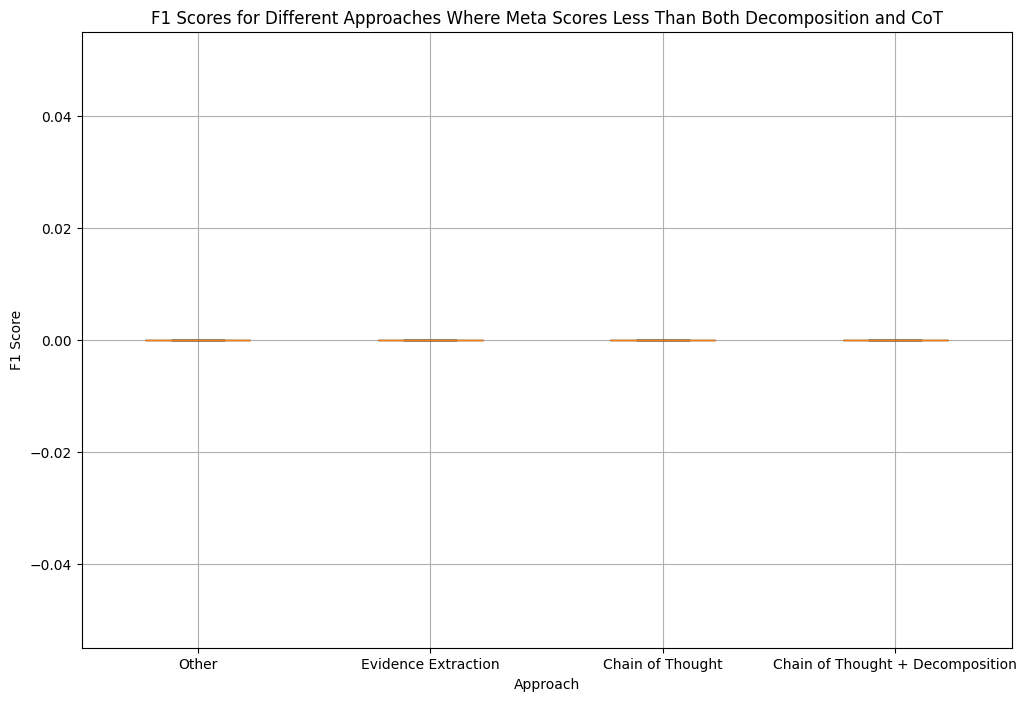

In [8]:
# Visualization of F1 scores for different approaches where Meta scores less than both Decomposition and CoT
plt.figure(figsize=(12, 8))
plt.boxplot([meta_less_than_both[meta_less_than_both['Meta Approach'] == approach]['f1_score_meta'] for approach in meta_less_than_both['Meta Approach'].unique()],
            labels=meta_less_than_both['Meta Approach'].unique(), patch_artist=True)
plt.title('F1 Scores for Different Approaches Where Meta Scores Less Than Both Decomposition and CoT')
plt.xlabel('Approach')
plt.ylabel('F1 Score')
plt.grid(True)
plt.show()

## Analysis of Cases Where Meta Scores Greater or Equal

In [9]:
# Filter rows where Meta F1 score is greater than or equal to both Decomposition and CoT F1 scores
meta_greater_equal_both = filtered_df_final[(filtered_df_final['f1_score_meta'] >= filtered_df_final['f1_score_decomposition']) & 
                                            (filtered_df_final['f1_score_meta'] >= filtered_df_final['f1_score_cot'])]

# Breakdown the F1 Scores of Meta against its approaches
f1_score_breakdown_greater_equal = meta_greater_equal_both.groupby('Meta Approach')['f1_score_meta'].describe()

# Generate summary of approaches it takes where it gets the answer correct or equal
approach_summary_correct_equal = meta_greater_equal_both['Meta Approach'].value_counts()
(f1_score_breakdown_greater_equal, approach_summary_correct_equal)

(Empty DataFrame
 Columns: [count, mean, std, min, 25%, 50%, 75%, max]
 Index: [],
 Series([], Name: count, dtype: int64))

In [16]:
meta_equal_or_greater = filtered_df_final[(filtered_df_final['f1_score_meta'] >= filtered_df_final['f1_score_decomposition']) | 
                                          (filtered_df_final['f1_score_meta'] > filtered_df_final['f1_score_cot'])]

meta_equal_or_greater

,question,response_meta,f1_score_meta,f1_score_decomposition,f1_score_cot,Meta Approach
50,in millions for the fourth quarters of 2017 an...,The provided table only contains data for the ...,0.0,0.0,100.0,Other
83,what is the percentage decrease in receivables...,**Chosen Approach:** Chain-of-Thought (CoT) Re...,0.0,0.0,100.0,Chain of Thought
174,what was the percentage change in non-interest...,**Chosen Approach:** Chain-of-Thought (CoT) Re...,0.0,0.0,100.0,Chain of Thought
198,"as of december 31 , 2005 , what was the before...",**Chosen Approach:** Evidence Extraction\n\n**...,0.0,0.0,100.0,Evidence Extraction
221,what was the sum of the annual long-term debt ...,**Chosen Approach:** Evidence Extraction\n\n**...,0.0,0.0,100.0,Evidence Extraction
305,"for 2011 and 2012 , what were average commerci...",**Chosen Approach**: Evidence Extraction and C...,0.0,0.0,100.0,Evidence Extraction
425,"in 2006 , what percent of unrealized loss did ...",**Chosen Approach:** Chain-of-Thought (CoT) Re...,0.0,0.0,100.0,Chain of Thought
482,what percent of contracts for long-term purcha...,## Reasoning Process:\n\n**1. Identify Relevan...,0.0,0.0,100.0,Other
539,by how much did the receivables from the money...,**Chosen Approach:** Chain-of-Thought (CoT) Re...,0.0,0.0,100.0,Chain of Thought
674,at the average grant date fair value per share...,**Chosen Approach:** Evidence Extraction\n\n**...,0.0,0.0,100.0,Evidence Extraction


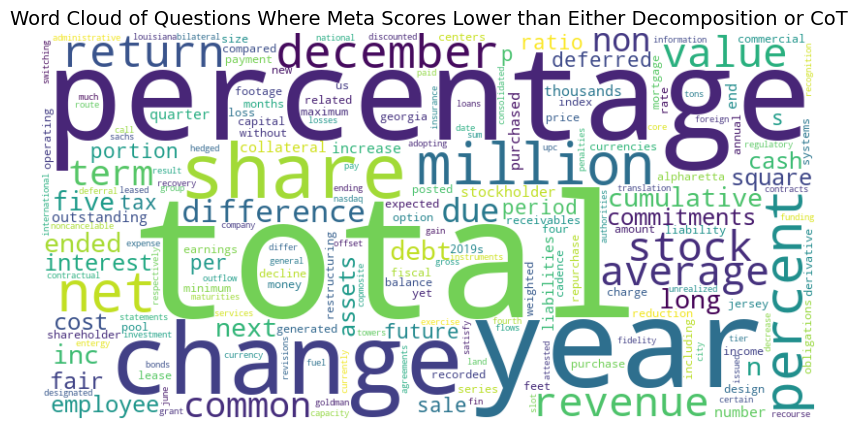

In [18]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt


decomposition_df_relevant = decomposition_df[['question', 'response', 'f1_score']]
cot_df_relevant = cot_df[['question', 'response', 'f1_score']]
meta_df_relevant = meta_df[['question', 'response', 'f1_score']]


merged_df = meta_df_relevant.merge(decomposition_df_relevant, on='question', suffixes=('_meta', '_decomposition'))
merged_df = merged_df.merge(cot_df_relevant, on='question', suffixes=('', '_cot'))


merged_df.rename(columns={'response': 'response_cot', 'f1_score': 'f1_score_cot'}, inplace=True)

filtered_df = merged_df[(merged_df['f1_score_meta'] < merged_df['f1_score_decomposition']) | (merged_df['f1_score_meta'] < merged_df['f1_score_cot'])]

questions_meta_lower_than_either_list = filtered_df['question'].tolist()

questions_text = ' '.join(questions_meta_lower_than_either_list)

wordcloud = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(questions_text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Questions Where Meta Scores Lower than Either Decomposition or CoT", fontsize=14)
plt.show()


In [20]:
better_than_meta = filtered_df_final[(filtered_df_final['f1_score_decomposition'] > filtered_df_final['f1_score_meta']) | 
                                     (filtered_df_final['f1_score_cot'] > filtered_df_final['f1_score_meta'])]


better_than_meta['Better Method'] = better_than_meta.apply(
    lambda row: 'Decomposition' if row['f1_score_decomposition'] > row['f1_score_meta'] and row['f1_score_decomposition'] >= row['f1_score_cot'] else (
                'CoT' if row['f1_score_cot'] > row['f1_score_meta'] and row['f1_score_cot'] >= row['f1_score_decomposition'] else 'Both'), axis=1)

better_than_meta[['question', 'f1_score_meta', 'f1_score_decomposition', 'f1_score_cot', 'Better Method', 'Meta Approach']]


,question,f1_score_meta,f1_score_decomposition,f1_score_cot,Better Method,Meta Approach
3,what was the percentage change in deferred tax...,0.0,100.000000,100.0,Decomposition,Other
7,what portion of the total noncancelable future...,0.0,100.000000,100.0,Decomposition,Evidence Extraction
13,"in 2004 and 2003 , what were the total shares ...",0.0,100.000000,100.0,Decomposition,Evidence Extraction
14,what was the percentage change in the commerci...,0.0,100.000000,0.0,Decomposition,Other
37,as of december 2007 what was the percent of th...,0.0,100.000000,0.0,Decomposition,Chain of Thought
...,...,...,...,...,...,...
942,what portion of the total future minimum commi...,0.0,100.000000,100.0,Decomposition,Evidence Extraction
944,what is the percentage change in the risk-free...,0.0,100.000000,100.0,Decomposition,Chain of Thought
951,in 2005 what was the percent of the total capi...,0.0,100.000000,100.0,Decomposition,Evidence Extraction
965,had all four quarters of 2010 had the same num...,0.0,100.000000,0.0,Decomposition,Chain of Thought


In [22]:
import pandas as pd
import re

# Load the CSV files
decomposition_df = pd.read_csv('/Users/harshavardhank/Desktop/Code/UPenn/TTQA-Recasting/Benchmark/src/scripts/models/responses/New/finqa/finqa_decomposition_results.csv')
cot_df = pd.read_csv('/Users/harshavardhank/Desktop/Code/UPenn/TTQA-Recasting/Benchmark/src/scripts/models/responses/New/finqa/finqa_cot_results.csv')
meta_df = pd.read_csv('/Users/harshavardhank/Desktop/Code/UPenn/TTQA-Recasting/Benchmark/src/scripts/models/responses/New/finqa/finqa_meta_results.csv')

# Extract relevant columns for comparison
decomposition_df_relevant = decomposition_df[['question', 'response', 'f1_score']]
cot_df_relevant = cot_df[['question', 'response', 'f1_score']]
meta_df_relevant = meta_df[['question', 'response', 'f1_score']]

# Merge the dataframes on the 'question' column to align responses and F1 scores
merged_df = meta_df_relevant.merge(decomposition_df_relevant, on='question', suffixes=('_meta', '_decomposition'))
merged_df = merged_df.merge(cot_df_relevant, on='question', suffixes=('', '_cot'))

# Rename CoT columns manually
merged_df.rename(columns={'response': 'response_cot', 'f1_score': 'f1_score_cot'}, inplace=True)

# Filter rows where Meta F1 score is less than either Decomposition or CoT F1 scores
filtered_df = merged_df[(merged_df['f1_score_meta'] < merged_df['f1_score_decomposition']) | (merged_df['f1_score_meta'] < merged_df['f1_score_cot'])]

# Define a function to mark the presence of different approaches including Python
def mark_approaches_with_python(text):
    approaches = {
        'Chain_of_Thought': False,
        'Decomposition': False,
        'Evidence_Extraction': False,
        'Python': False,
        'Other': False
    }
    
    # Define regex patterns for different approaches
    patterns = {
        'Chain_of_Thought': r'\bchain[-\s]of[-\s]thought\b',
        'Decomposition': r'\bdecomposition\b',
        'Evidence_Extraction': r'\bevidence extraction\b',
        'Python': r'\bpython\b'
    }
    
    found = False
    for approach, pattern in patterns.items():
        if re.search(pattern, text, re.IGNORECASE):
            approaches[approach] = True
            found = True
    
    if re.search(patterns['Chain_of_Thought'], text, re.IGNORECASE) and re.search(patterns['Evidence_Extraction'], text, re.IGNORECASE):
        approaches['Chain_of_Thought'] = True
        approaches['Evidence_Extraction'] = True
    
    if re.search(patterns['Decomposition'], text, re.IGNORECASE) and re.search(patterns['Evidence_Extraction'], text, re.IGNORECASE):
        approaches['Decomposition'] = True
        approaches['Evidence_Extraction'] = True
    
    if not found:
        approaches['Other'] = True
    
    return pd.Series(approaches)

# Apply the function to the 'response_meta' column to mark approaches including Python
marked_approaches_with_python = filtered_df['response_meta'].apply(mark_approaches_with_python)

# Combine the original dataframe with the new columns for marked approaches
result_df_with_python = pd.concat([filtered_df, marked_approaches_with_python], axis=1)

# Save the resulting dataframe to a CSV file
result_df_with_python.to_csv('meta_responses_with_marked_approaches.csv', index=False)

# Display the resulting dataframe
result_df_with_python


,question,response_meta,f1_score_meta,response_decomposition,f1_score_decomposition,response_cot,f1_score_cot,Chain_of_Thought,Decomposition,Evidence_Extraction,Python,Other
3,what was the percentage change in deferred tax...,The table does not contain the necessary infor...,0.0,```\ndecomposition:\n sq1. What was the value...,100.000000,reason: The percentage change in deferred tax ...,100.0,False,False,False,False,True
7,what portion of the total noncancelable future...,**Chosen Approach**: Evidence Extraction\n\n**...,0.0,## Decomposition:\n\n**sq1.** What is the valu...,100.000000,reason: The total noncancelable future lease c...,100.0,False,False,True,False,False
13,"in 2004 and 2003 , what were the total shares ...",**Chosen Approach:** Evidence Extraction\n\n**...,0.0,"```json\n{\n ""decomposition"": [\n ""sq1. What ...",100.000000,reasoning: The table shows the number of share...,100.0,False,False,True,False,False
14,what was the percentage change in the commerci...,The provided table and text do not contain inf...,0.0,"```json\n{\n ""decomposition"": [\n ""sq1. What ...",100.000000,reason: The provided table shows the value of ...,0.0,False,False,False,False,True
37,as of december 2007 what was the percent of th...,**Chosen Approach:** Chain-of-Thought (CoT) Re...,0.0,## Decomposition:\n\n**sq1.** What is the tota...,100.000000,reason: 'The table states that all facilities ...,0.0,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
942,what portion of the total future minimum commi...,**Chosen Approach:** Evidence Extraction\n\n**...,0.0,## Decomposition:\n\n**sq1.** What are the fut...,100.000000,reasoning: 'To find the portion of total futur...,100.0,False,False,True,False,False
944,what is the percentage change in the risk-free...,**Chosen Approach:** Chain-of-Thought (CoT) Re...,0.0,## Decomposition:\n\n**sq1.** What was the ris...,100.000000,reasoning: 'The risk-free rate in 2003 was 2.9...,100.0,True,False,False,False,False
951,in 2005 what was the percent of the total capi...,**Chosen Approach:** Evidence Extraction and C...,0.0,## Decomposition:\n\n**sq1:** What was the cap...,100.000000,reasoning: 'To determine the percentage of tot...,100.0,False,False,True,False,False
965,had all four quarters of 2010 had the same num...,**Chosen Approach:** Chain-of-Thought (CoT) Re...,0.0,## Decomposition:\n\n**sq1.** What is the tota...,100.000000,reason: 'To find the total number of shares pu...,0.0,True,False,False,False,False


In [25]:
multiple_methods_used = result_df_with_python[
    (result_df_with_python[['Chain_of_Thought', 'Decomposition', 'Evidence_Extraction', 'Python']].sum(axis=1) > 1)
]

multiple_methods_summary = multiple_methods_used[['question', 'response_meta', 'Chain_of_Thought', 'Decomposition', 'Evidence_Extraction', 'Python']].to_dict(orient='records')

len(multiple_methods_summary)


2

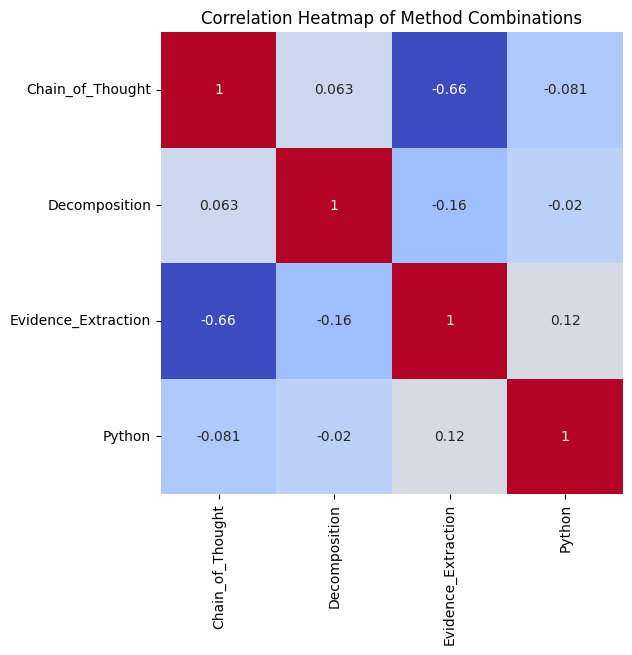

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the combinations of methods used
method_combinations = result_df_with_python[
    ['Chain_of_Thought', 'Decomposition', 'Evidence_Extraction', 'Python']
].sum(axis=0)

# Create a heatmap to visualize the combinations
plt.figure(figsize=(8, 6))
sns.heatmap(
    result_df_with_python[
        ['Chain_of_Thought', 'Decomposition', 'Evidence_Extraction', 'Python']
    ].corr(), annot=True, cmap='coolwarm', cbar=False, square=True
)
plt.title('Correlation Heatmap of Method Combinations')
plt.show()


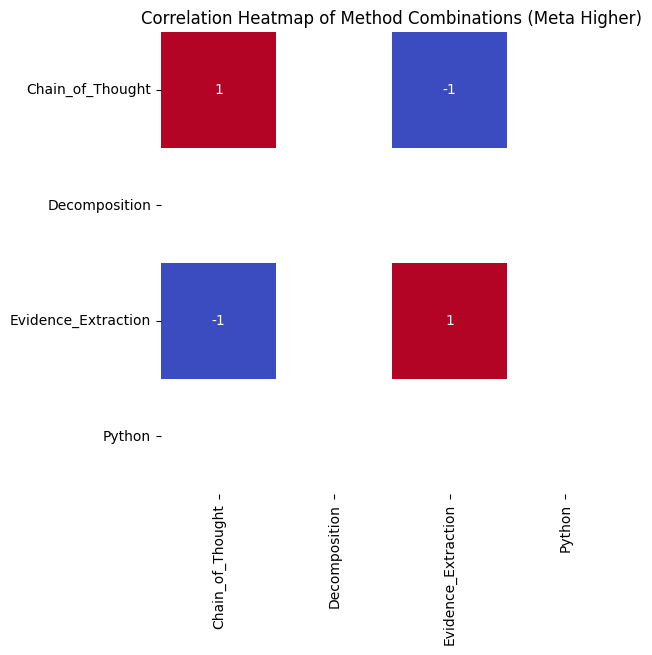

In [28]:
# Filter rows where Meta F1 score is higher than both Decomposition and CoT F1 scores
meta_higher = merged_df[(merged_df['f1_score_meta'] > merged_df['f1_score_decomposition']) & 
                        (merged_df['f1_score_meta'] > merged_df['f1_score_cot'])]

# Define a function to mark the presence of different approaches including Python
def mark_approaches(text):
    approaches = {
        'Chain_of_Thought': False,
        'Decomposition': False,
        'Evidence_Extraction': False,
        'Python': False,
        'Other': False
    }
    
    # Define regex patterns for different approaches
    patterns = {
        'Chain_of_Thought': r'\bchain[-\s]of[-\s]thought\b',
        'Decomposition': r'\bdecomposition\b',
        'Evidence_Extraction': r'\bevidence extraction\b',
        'Python': r'\bpython\b'
    }
    
    found = False
    for approach, pattern in patterns.items():
        if re.search(pattern, text, re.IGNORECASE):
            approaches[approach] = True
            found = True
    
    if re.search(patterns['Chain_of_Thought'], text, re.IGNORECASE) and re.search(patterns['Evidence_Extraction'], text, re.IGNORECASE):
        approaches['Chain_of_Thought'] = True
        approaches['Evidence_Extraction'] = True
    
    if re.search(patterns['Decomposition'], text, re.IGNORECASE) and re.search(patterns['Evidence_Extraction'], text, re.IGNORECASE):
        approaches['Decomposition'] = True
        approaches['Evidence_Extraction'] = True
    
    if not found:
        approaches['Other'] = True
    
    return pd.Series(approaches)

# Apply the function to the 'response_meta' column to mark approaches
marked_approaches_higher = meta_higher['response_meta'].apply(mark_approaches)

# Combine the original dataframe with the new columns for marked approaches
result_df_higher = pd.concat([meta_higher, marked_approaches_higher], axis=1)

# Count the combinations of methods used
method_combinations_higher = result_df_higher[
    ['Chain_of_Thought', 'Decomposition', 'Evidence_Extraction', 'Python']
].sum(axis=0)

# Create a heatmap to visualize the combinations
plt.figure(figsize=(8, 6))
sns.heatmap(
    result_df_higher[
        ['Chain_of_Thought', 'Decomposition', 'Evidence_Extraction', 'Python']
    ].corr(), annot=True, cmap='coolwarm', cbar=False, square=True
)
plt.title('Correlation Heatmap of Method Combinations (Meta Higher)')
plt.show()
